# División Estratificada del Dataset
## Clasificador de Noticias: Actualidad vs Interés General

Este notebook realiza la división estratificada del dataset en conjuntos de entrenamiento, validación y prueba.

**Objetivos:**
1. Cargar el dataset preprocesado
2. Dividir estratificadamente: 70% train, 20% validation, 10% test
3. Verificar distribución de clases en cada split
4. Generar test_public.csv (sin etiquetas) y test_labels.csv
5. Guardar todos los splits

**Criterios técnicos:**
- Split estratificado para mantener proporción de clases
- No duplicados entre conjuntos
- Reproducibilidad (random_state fijo)

In [1]:
# Importar librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

# Establecer semilla para reproducibilidad
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Librerías importadas exitosamente")
print(f"Random state fijo: {RANDOM_STATE}")

Librerías importadas exitosamente
Random state fijo: 42


## 1. Cargar Dataset Preprocesado

In [2]:
# Cargar dataset preprocesado
df = pd.read_csv('../data/processed/dataset_preprocessed.csv')
print(f"Dataset cargado: {len(df):,} registros")
print(f"\nColumnas: {df.columns.tolist()}")
print(f"\nDistribución de clases:")
print(df['label'].value_counts().sort_index())
print(f"\nPorcentaje:")
print((df['label'].value_counts(normalize=True).sort_index() * 100).round(2))

# Verificar que no haya valores faltantes
print(f"\nValores faltantes:")
print(df.isnull().sum())

Dataset cargado: 207,339 registros

Columnas: ['doc_id', 'text', 'label', 'class_name', 'source', 'category']

Distribución de clases:
label
0     81540
1    125799
Name: count, dtype: int64

Porcentaje:
label
0    39.33
1    60.67
Name: proportion, dtype: float64

Valores faltantes:
doc_id        0
text          0
label         0
class_name    0
source        0
category      0
dtype: int64


In [3]:
# Mostrar primeras filas
display(df.head())

,doc_id,text,label,class_name,source,category
0,N88753,"The Brands Queen Elizabeth, Prince Charles, an...",1,Interés General,MIND,lifestyle
1,N45436,Walmart Slashes Prices on Last-Generation iPads,0,Actualidad,MIND,news
2,N23144,50 Worst Habits For Belly Fat,1,Interés General,MIND,health
3,N86255,Dispose of unwanted prescription drugs during ...,1,Interés General,MIND,health
4,N93187,The Cost of Trump's Aid Freeze in the Trenches...,0,Actualidad,MIND,news


## 2. División Estratificada del Dataset

### Estrategia:
- **70% Training**: Para entrenar los modelos
- **20% Validation**: Para ajustar hiperparámetros y selección de modelos
- **10% Test**: Para evaluación final (guardado por separado para el instructor)

In [4]:
# Separar features y labels
X = df[['doc_id', 'text', 'source', 'category']]
y = df['label']

print(f"Total de muestras: {len(X):,}")
print(f"\nDistribución de clases en dataset completo:")
print(y.value_counts().sort_index())

Total de muestras: 207,339

Distribución de clases en dataset completo:
label
0     81540
1    125799
Name: count, dtype: int64


In [5]:
# Primer split: Separar test set (10%)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, 
    test_size=0.10, 
    stratify=y, 
    random_state=RANDOM_STATE
)

print(f"Después del primer split:")
print(f"  - Conjunto temporal (train+val): {len(X_temp):,} ({len(X_temp)/len(X)*100:.1f}%)")
print(f"  - Conjunto de test: {len(X_test):,} ({len(X_test)/len(X)*100:.1f}%)")

Después del primer split:
  - Conjunto temporal (train+val): 186,605 (90.0%)
  - Conjunto de test: 20,734 (10.0%)


In [6]:
# Segundo split: Dividir temp en train (70%) y validation (20%)
# Como temp es 90%, necesitamos 70/90 ≈ 0.778 para train y 20/90 ≈ 0.222 para val
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, 
    test_size=0.222,  # 20% del total original
    stratify=y_temp, 
    random_state=RANDOM_STATE
)

print(f"\nDespués del segundo split:")
print(f"  - Conjunto de entrenamiento: {len(X_train):,} ({len(X_train)/len(X)*100:.1f}%)")
print(f"  - Conjunto de validación: {len(X_val):,} ({len(X_val)/len(X)*100:.1f}%)")
print(f"  - Conjunto de test: {len(X_test):,} ({len(X_test)/len(X)*100:.1f}%)")

total_splits = len(X_train) + len(X_val) + len(X_test)
print(f"\nTotal en splits: {total_splits:,}")
print(f"Total original: {len(X):,}")
print(f"Verificación: {total_splits == len(X)}")


Después del segundo split:
  - Conjunto de entrenamiento: 145,178 (70.0%)
  - Conjunto de validación: 41,427 (20.0%)
  - Conjunto de test: 20,734 (10.0%)

Total en splits: 207,339
Total original: 207,339
Verificación: True


## 3. Verificación de Estratificación

In [7]:
# Función para mostrar distribución de clases
def show_class_distribution(y_set, set_name):
    counts = y_set.value_counts().sort_index()
    percentages = (y_set.value_counts(normalize=True).sort_index() * 100)
    
    print(f"\n{set_name}:")
    print(f"  Total: {len(y_set):,} muestras")
    for label in sorted(y_set.unique()):
        count = counts[label]
        pct = percentages[label]
        class_name = 'Actualidad' if label == 0 else 'Interés General'
        print(f"  Clase {label} ({class_name}): {count:,} ({pct:.2f}%)")

print("="*60)
print("DISTRIBUCIÓN DE CLASES EN CADA SPLIT")
print("="*60)

show_class_distribution(y, "Dataset Original")
show_class_distribution(y_train, "Conjunto de Entrenamiento")
show_class_distribution(y_val, "Conjunto de Validación")
show_class_distribution(y_test, "Conjunto de Test")

print("\n" + "="*60)

DISTRIBUCIÓN DE CLASES EN CADA SPLIT

Dataset Original:
  Total: 207,339 muestras
  Clase 0 (Actualidad): 81,540 (39.33%)
  Clase 1 (Interés General): 125,799 (60.67%)

Conjunto de Entrenamiento:
  Total: 145,178 muestras
  Clase 0 (Actualidad): 57,094 (39.33%)
  Clase 1 (Interés General): 88,084 (60.67%)

Conjunto de Validación:
  Total: 41,427 muestras
  Clase 0 (Actualidad): 16,292 (39.33%)
  Clase 1 (Interés General): 25,135 (60.67%)

Conjunto de Test:
  Total: 20,734 muestras
  Clase 0 (Actualidad): 8,154 (39.33%)
  Clase 1 (Interés General): 12,580 (60.67%)



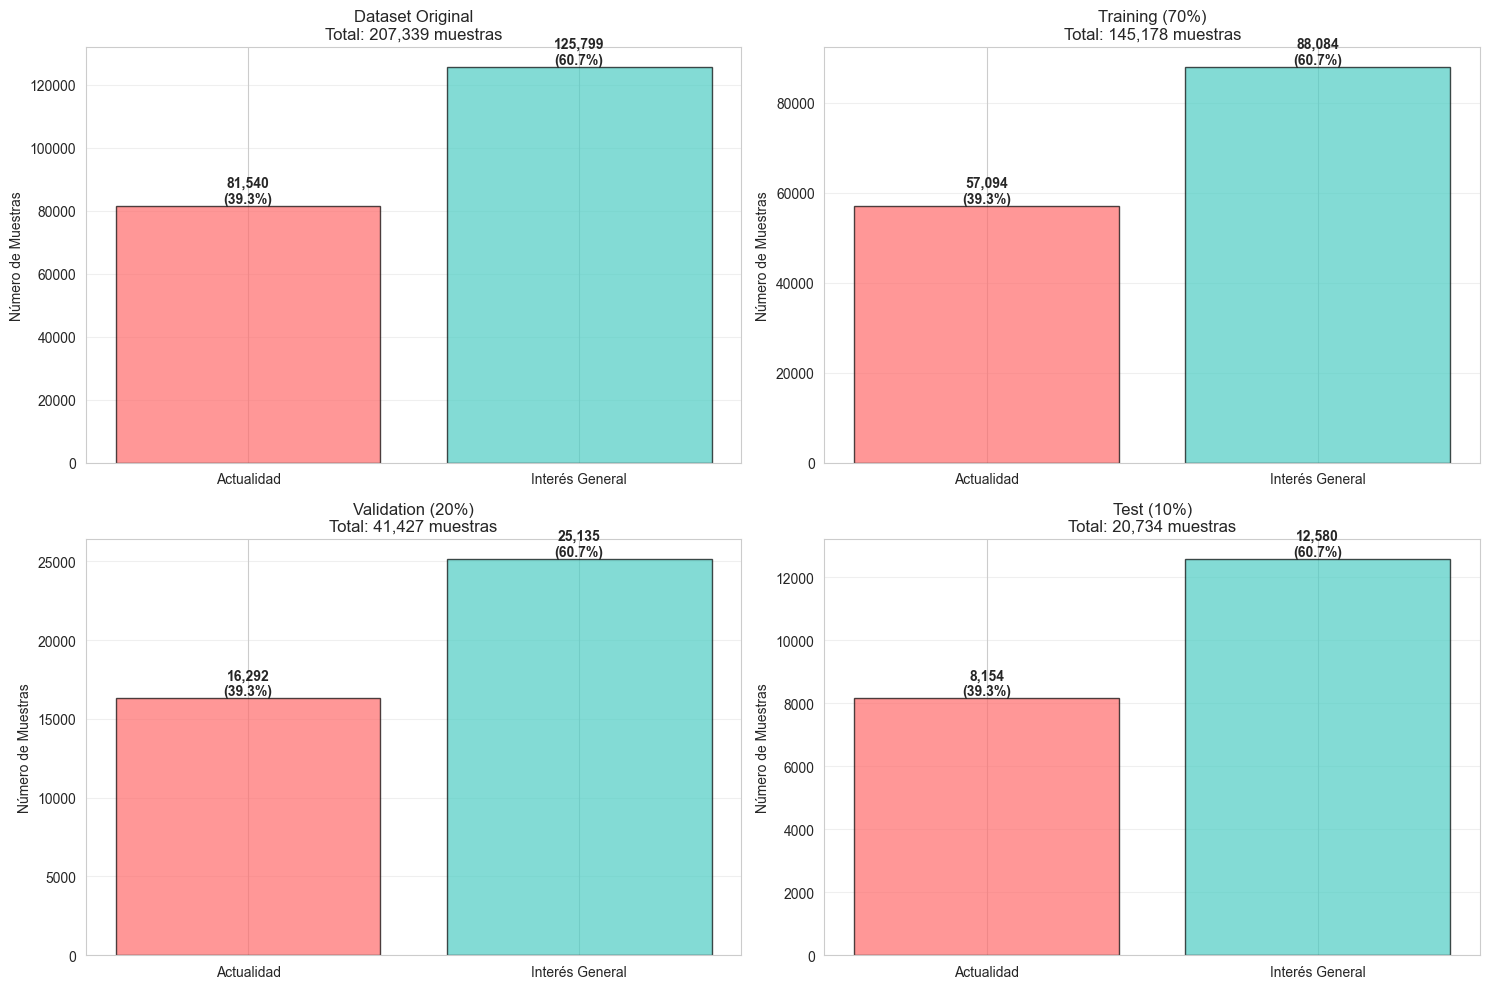

Gráfico guardado en: ../results/split_distribution.png


In [8]:
# Visualización de distribución de clases en cada split
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

datasets = [
    (y, 'Dataset Original', axes[0, 0]),
    (y_train, 'Training (70%)', axes[0, 1]),
    (y_val, 'Validation (20%)', axes[1, 0]),
    (y_test, 'Test (10%)', axes[1, 1])
]

colors = ['#FF6B6B', '#4ECDC4']
labels_names = ['Actualidad', 'Interés General']

for y_set, title, ax in datasets:
    counts = y_set.value_counts().sort_index()
    percentages = (y_set.value_counts(normalize=True).sort_index() * 100)
    
    bars = ax.bar([0, 1], counts.values, color=colors, edgecolor='black', alpha=0.7)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(labels_names)
    ax.set_ylabel('Número de Muestras')
    ax.set_title(f'{title}\nTotal: {len(y_set):,} muestras')
    ax.grid(axis='y', alpha=0.3)
    
    # Añadir valores y porcentajes en las barras
    for i, (bar, count, pct) in enumerate(zip(bars, counts.values, percentages.values)):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{count:,}\n({pct:.1f}%)',
                ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('../results/split_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("Gráfico guardado en: ../results/split_distribution.png")

## 4. Verificación de No Duplicación entre Splits

In [9]:
# Verificar que no haya documentos duplicados entre splits
train_ids = set(X_train['doc_id'])
val_ids = set(X_val['doc_id'])
test_ids = set(X_test['doc_id'])

print("="*60)
print("VERIFICACIÓN DE NO DUPLICACIÓN ENTRE SPLITS")
print("="*60)

# Verificar intersecciones
train_val_overlap = train_ids.intersection(val_ids)
train_test_overlap = train_ids.intersection(test_ids)
val_test_overlap = val_ids.intersection(test_ids)

print(f"\nDocumentos compartidos entre Train y Val: {len(train_val_overlap)}")
print(f"Documentos compartidos entre Train y Test: {len(train_test_overlap)}")
print(f"Documentos compartidos entre Val y Test: {len(val_test_overlap)}")

if len(train_val_overlap) == 0 and len(train_test_overlap) == 0 and len(val_test_overlap) == 0:
    print(f"\n✓ VERIFICACIÓN EXITOSA: No hay documentos duplicados entre splits")
else:
    print(f"\n⚠️ ADVERTENCIA: Se encontraron documentos duplicados entre splits")

print("="*60)

VERIFICACIÓN DE NO DUPLICACIÓN ENTRE SPLITS

Documentos compartidos entre Train y Val: 0
Documentos compartidos entre Train y Test: 0
Documentos compartidos entre Val y Test: 0

✓ VERIFICACIÓN EXITOSA: No hay documentos duplicados entre splits


## 5. Crear DataFrames Completos para cada Split

In [10]:
# Combinar X e y para crear DataFrames completos
train_df = X_train.copy()
train_df['label'] = y_train.values
train_df['class_name'] = train_df['label'].map({0: 'Actualidad', 1: 'Interés General'})

val_df = X_val.copy()
val_df['label'] = y_val.values
val_df['class_name'] = val_df['label'].map({0: 'Actualidad', 1: 'Interés General'})

test_df = X_test.copy()
test_df['label'] = y_test.values
test_df['class_name'] = test_df['label'].map({0: 'Actualidad', 1: 'Interés General'})

print("DataFrames creados exitosamente:")
print(f"  - train_df: {len(train_df):,} registros")
print(f"  - val_df: {len(val_df):,} registros")
print(f"  - test_df: {len(test_df):,} registros")

DataFrames creados exitosamente:
  - train_df: 145,178 registros
  - val_df: 41,427 registros
  - test_df: 20,734 registros


## 6. Generar Archivos de Test para el Instructor

In [11]:
# test_public.csv - Sin etiquetas (para evaluación)
test_public = test_df[['doc_id', 'text']].copy()

# test_labels.csv - Solo etiquetas (para revisión del docente)
test_labels = test_df[['doc_id', 'label', 'class_name']].copy()

print("Archivos de test generados:")
print(f"\ntest_public.csv (sin etiquetas):")
print(f"  Columnas: {test_public.columns.tolist()}")
print(f"  Registros: {len(test_public):,}")
display(test_public.head())

print(f"\ntest_labels.csv (solo etiquetas):")
print(f"  Columnas: {test_labels.columns.tolist()}")
print(f"  Registros: {len(test_labels):,}")
display(test_labels.head())

Archivos de test generados:

test_public.csv (sin etiquetas):
  Columnas: ['doc_id', 'text']
  Registros: 20,734


,doc_id,text
78873,N5275,Bobby Orr defended Don Cherry
177409,GOOGLE81018,What Omicron's BA.4 and BA.5 variants mean for...
192775,GOOGLE96384,"Bechtolsheimer Purchases Lola Cars Brand, Tech..."
55426,N52726,Giants' Pat Shurmur again defends his late fou...
50710,N61068,Chargers ready for one final scene in Oakland ...



test_labels.csv (solo etiquetas):
  Columnas: ['doc_id', 'label', 'class_name']
  Registros: 20,734


,doc_id,label,class_name
78873,N5275,1,Interés General
177409,GOOGLE81018,0,Actualidad
192775,GOOGLE96384,1,Interés General
55426,N52726,1,Interés General
50710,N61068,1,Interés General


## 7. Guardar Todos los Splits

In [12]:
# Guardar splits completos
train_df.to_csv('../data/splits/train.csv', index=False)
val_df.to_csv('../data/splits/val.csv', index=False)
test_df.to_csv('../data/splits/test.csv', index=False)

print("Splits guardados:")
print("  ✓ ../data/splits/train.csv")
print("  ✓ ../data/splits/val.csv")
print("  ✓ ../data/splits/test.csv")

# Guardar archivos de test para el instructor
test_public.to_csv('../test_sets/test_public.csv', index=False)
test_labels.to_csv('../test_sets/test_labels.csv', index=False)

print("\nArchivos de test para instructor guardados:")
print("  ✓ ../test_sets/test_public.csv (sin etiquetas)")
print("  ✓ ../test_sets/test_labels.csv (solo etiquetas)")

Splits guardados:
  ✓ ../data/splits/train.csv
  ✓ ../data/splits/val.csv
  ✓ ../data/splits/test.csv

Archivos de test para instructor guardados:
  ✓ ../test_sets/test_public.csv (sin etiquetas)
  ✓ ../test_sets/test_labels.csv (solo etiquetas)


## 8. Resumen de la División Estratificada

In [13]:
print("="*70)
print("RESUMEN DE LA DIVISIÓN ESTRATIFICADA DEL DATASET")
print("="*70)

print(f"\n1. CONFIGURACIÓN:")
print(f"   - Random State: {RANDOM_STATE}")
print(f"   - Estratificación: Sí (mantiene proporción de clases)")
print(f"   - Sin duplicados entre splits: Verificado ✓")

print(f"\n2. SPLITS GENERADOS:")
print(f"   - Training:   {len(train_df):,} ({len(train_df)/len(df)*100:.1f}%) - train.csv")
print(f"   - Validation: {len(val_df):,} ({len(val_df)/len(df)*100:.1f}%) - val.csv")
print(f"   - Test:       {len(test_df):,} ({len(test_df)/len(df)*100:.1f}%) - test.csv")
print(f"   - TOTAL:      {len(train_df) + len(val_df) + len(test_df):,}")

print(f"\n3. DISTRIBUCIÓN DE CLASES EN CADA SPLIT:")

# Training
train_class0 = (train_df['label'] == 0).sum()
train_class1 = (train_df['label'] == 1).sum()
print(f"   Training:")
print(f"     - Clase 0 (Actualidad): {train_class0:,} ({train_class0/len(train_df)*100:.2f}%)")
print(f"     - Clase 1 (Interés General): {train_class1:,} ({train_class1/len(train_df)*100:.2f}%)")

# Validation
val_class0 = (val_df['label'] == 0).sum()
val_class1 = (val_df['label'] == 1).sum()
print(f"   Validation:")
print(f"     - Clase 0 (Actualidad): {val_class0:,} ({val_class0/len(val_df)*100:.2f}%)")
print(f"     - Clase 1 (Interés General): {val_class1:,} ({val_class1/len(val_df)*100:.2f}%)")

# Test
test_class0 = (test_df['label'] == 0).sum()
test_class1 = (test_df['label'] == 1).sum()
print(f"   Test:")
print(f"     - Clase 0 (Actualidad): {test_class0:,} ({test_class0/len(test_df)*100:.2f}%)")
print(f"     - Clase 1 (Interés General): {test_class1:,} ({test_class1/len(test_df)*100:.2f}%)")

print(f"\n4. ARCHIVOS GENERADOS PARA EL INSTRUCTOR:")
print(f"   - test_public.csv: {len(test_public):,} registros (sin etiquetas)")
print(f"   - test_labels.csv: {len(test_labels):,} registros (solo etiquetas)")

print(f"\n5. PRÓXIMOS PASOS:")
print(f"   - Vectorización de texto (TF-IDF, embeddings)")
print(f"   - Entrenamiento de modelos de clasificación")
print(f"   - Evaluación y optimización de hiperparámetros")
print(f"   - Evaluación final en conjunto de test")

print("="*70)

RESUMEN DE LA DIVISIÓN ESTRATIFICADA DEL DATASET

1. CONFIGURACIÓN:
   - Random State: 42
   - Estratificación: Sí (mantiene proporción de clases)
   - Sin duplicados entre splits: Verificado ✓

2. SPLITS GENERADOS:
   - Training:   145,178 (70.0%) - train.csv
   - Validation: 41,427 (20.0%) - val.csv
   - Test:       20,734 (10.0%) - test.csv
   - TOTAL:      207,339

3. DISTRIBUCIÓN DE CLASES EN CADA SPLIT:
   Training:
     - Clase 0 (Actualidad): 57,094 (39.33%)
     - Clase 1 (Interés General): 88,084 (60.67%)
   Validation:
     - Clase 0 (Actualidad): 16,292 (39.33%)
     - Clase 1 (Interés General): 25,135 (60.67%)
   Test:
     - Clase 0 (Actualidad): 8,154 (39.33%)
     - Clase 1 (Interés General): 12,580 (60.67%)

4. ARCHIVOS GENERADOS PARA EL INSTRUCTOR:
   - test_public.csv: 20,734 registros (sin etiquetas)
   - test_labels.csv: 20,734 registros (solo etiquetas)

5. PRÓXIMOS PASOS:
   - Vectorización de texto (TF-IDF, embeddings)
   - Entrenamiento de modelos de clasificac

## 9. Tabla de Resumen

In [14]:
# Crear tabla resumen
summary_data = {
    'Split': ['Training', 'Validation', 'Test', 'TOTAL'],
    'Total': [
        len(train_df),
        len(val_df),
        len(test_df),
        len(train_df) + len(val_df) + len(test_df)
    ],
    'Porcentaje (%)': [
        f"{len(train_df)/len(df)*100:.1f}",
        f"{len(val_df)/len(df)*100:.1f}",
        f"{len(test_df)/len(df)*100:.1f}",
        "100.0"
    ],
    'Clase 0 (Actualidad)': [
        f"{train_class0:,} ({train_class0/len(train_df)*100:.1f}%)",
        f"{val_class0:,} ({val_class0/len(val_df)*100:.1f}%)",
        f"{test_class0:,} ({test_class0/len(test_df)*100:.1f}%)",
        f"{train_class0 + val_class0 + test_class0:,}"
    ],
    'Clase 1 (Interés General)': [
        f"{train_class1:,} ({train_class1/len(train_df)*100:.1f}%)",
        f"{val_class1:,} ({val_class1/len(val_df)*100:.1f}%)",
        f"{test_class1:,} ({test_class1/len(test_df)*100:.1f}%)",
        f"{train_class1 + val_class1 + test_class1:,}"
    ]
}

summary_df = pd.DataFrame(summary_data)

print("\n=== TABLA RESUMEN DE SPLITS ===")
display(summary_df)

# Guardar tabla resumen
summary_df.to_csv('../results/split_summary.csv', index=False)
print("\nTabla resumen guardada en: ../results/split_summary.csv")


=== TABLA RESUMEN DE SPLITS ===


,Split,Total,Porcentaje (%),Clase 0 (Actualidad),Clase 1 (Interés General)
0,Training,145178,70.0,"57,094 (39.3%)","88,084 (60.7%)"
1,Validation,41427,20.0,"16,292 (39.3%)","25,135 (60.7%)"
2,Test,20734,10.0,"8,154 (39.3%)","12,580 (60.7%)"
3,TOTAL,207339,100.0,"81,540","125,799"



Tabla resumen guardada en: ../results/split_summary.csv
